In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

In [2]:
# ==============================
# LOAD DATASET
# ==============================
df_kidney = pd.read_csv("kidney.csv")

# Clean column names
df_kidney.columns = df_kidney.columns.str.strip().str.lower()

df_kidney.head()

,"id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification"
0,"1,58.0,86.0,1.005,1.0,5.0,abnormal,abnormal,no..."
1,"2,71.0,146.0,1.005,0.0,5.0,Abnormal,abnormal,,..."
2,"3,48.0,96.0,1.005,,1.0,abnormal,abnormal,notpr..."
3,"4,,112.0,1.025,2.0,3.0,normal,abnormal,notpres..."
4,"5,,127.0,,,1.0, abnormal,abnormal,notpresent,n..."


In [3]:
# ==============================
# DATA UNDERSTANDING
# ==============================

print("Shape:", df_kidney.shape)

Shape: (400, 1)


In [4]:
print("\nInfo:")
print(df_kidney.info())


Info:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 1 columns):
 #   Column                                                                                                    Non-Null Count  Dtype
---  ------                                                                                                    --------------  -----
 0   id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification  400 non-null    str  
dtypes: str(1)
memory usage: 3.3 KB
None


In [5]:
print("\nMissing Values:")
print(df_kidney.isnull().sum())


Missing Values:
id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification    0
dtype: int64


In [6]:
print("\nStatistical Summary:")
print(df_kidney.describe())


Statistical Summary:
       id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count                                                 400                                                      
unique                                                400                                                      
top     1,58.0,86.0,1.005,1.0,5.0,abnormal,abnormal,no...                                                      
freq                                                    1                                                      


In [7]:
# ==============================
# CLEAN TARGET SAFELY
# ==============================

# Fix malformed single-column load if needed
if "classification" not in df_kidney.columns and df_kidney.shape[1] == 1:
    first_col = df_kidney.columns[0]
    df_kidney = df_kidney[first_col].astype(str).str.split(",", expand=True)
    df_kidney.columns = [c.strip().lower() for c in first_col.split(",")]

# Normalize column names
df_kidney.columns = df_kidney.columns.astype(str).str.strip().str.lower()

if "classification" not in df_kidney.columns:
    raise KeyError(
        "classification column not found in df_kidney after loading the dataset."
    )

# Convert to string first (safe)
df_kidney["classification"] = (
    df_kidney["classification"].astype(str).str.strip().str.lower()
)

# Map values
df_kidney["classification"] = df_kidney["classification"].map(
    {"ckd": 1, "notckd": 0, "not ckd": 0, "1": 1, "0": 0}
)

# Drop rows where mapping failed
df_kidney = df_kidney.dropna(subset=["classification"])

# Convert to numeric safely
for col in df_kidney.columns:
    if col != "classification":
        df_kidney[col] = pd.to_numeric(df_kidney[col], errors="coerce")

# Fill missing values
df_kidney.fillna(df_kidney.median(numeric_only=True), inplace=True)

# Remove duplicates
df_kidney = df_kidney.drop_duplicates()
df_kidney = df_kidney.dropna(axis=1, how="all")
df_kidney.fillna(df_kidney.median(numeric_only=True), inplace=True)

# Remove columns with only one unique value
for col in df_kidney.columns:
    if df_kidney[col].nunique() <= 1:
        df_kidney.drop(col, axis=1, inplace=True)

In [8]:
# ==============================
# DATA PREPARATION
# ==============================

X = df_kidney.drop("classification", axis=1)
y = df_kidney["classification"]

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

print("Before SMOTE:", y.value_counts().to_dict())

# Apply SMOTE first (before scaling)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

# Then scale the resampled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

Before SMOTE: {1.0: 266, 0.0: 94}
After SMOTE: {1.0: 266, 0.0: 266}


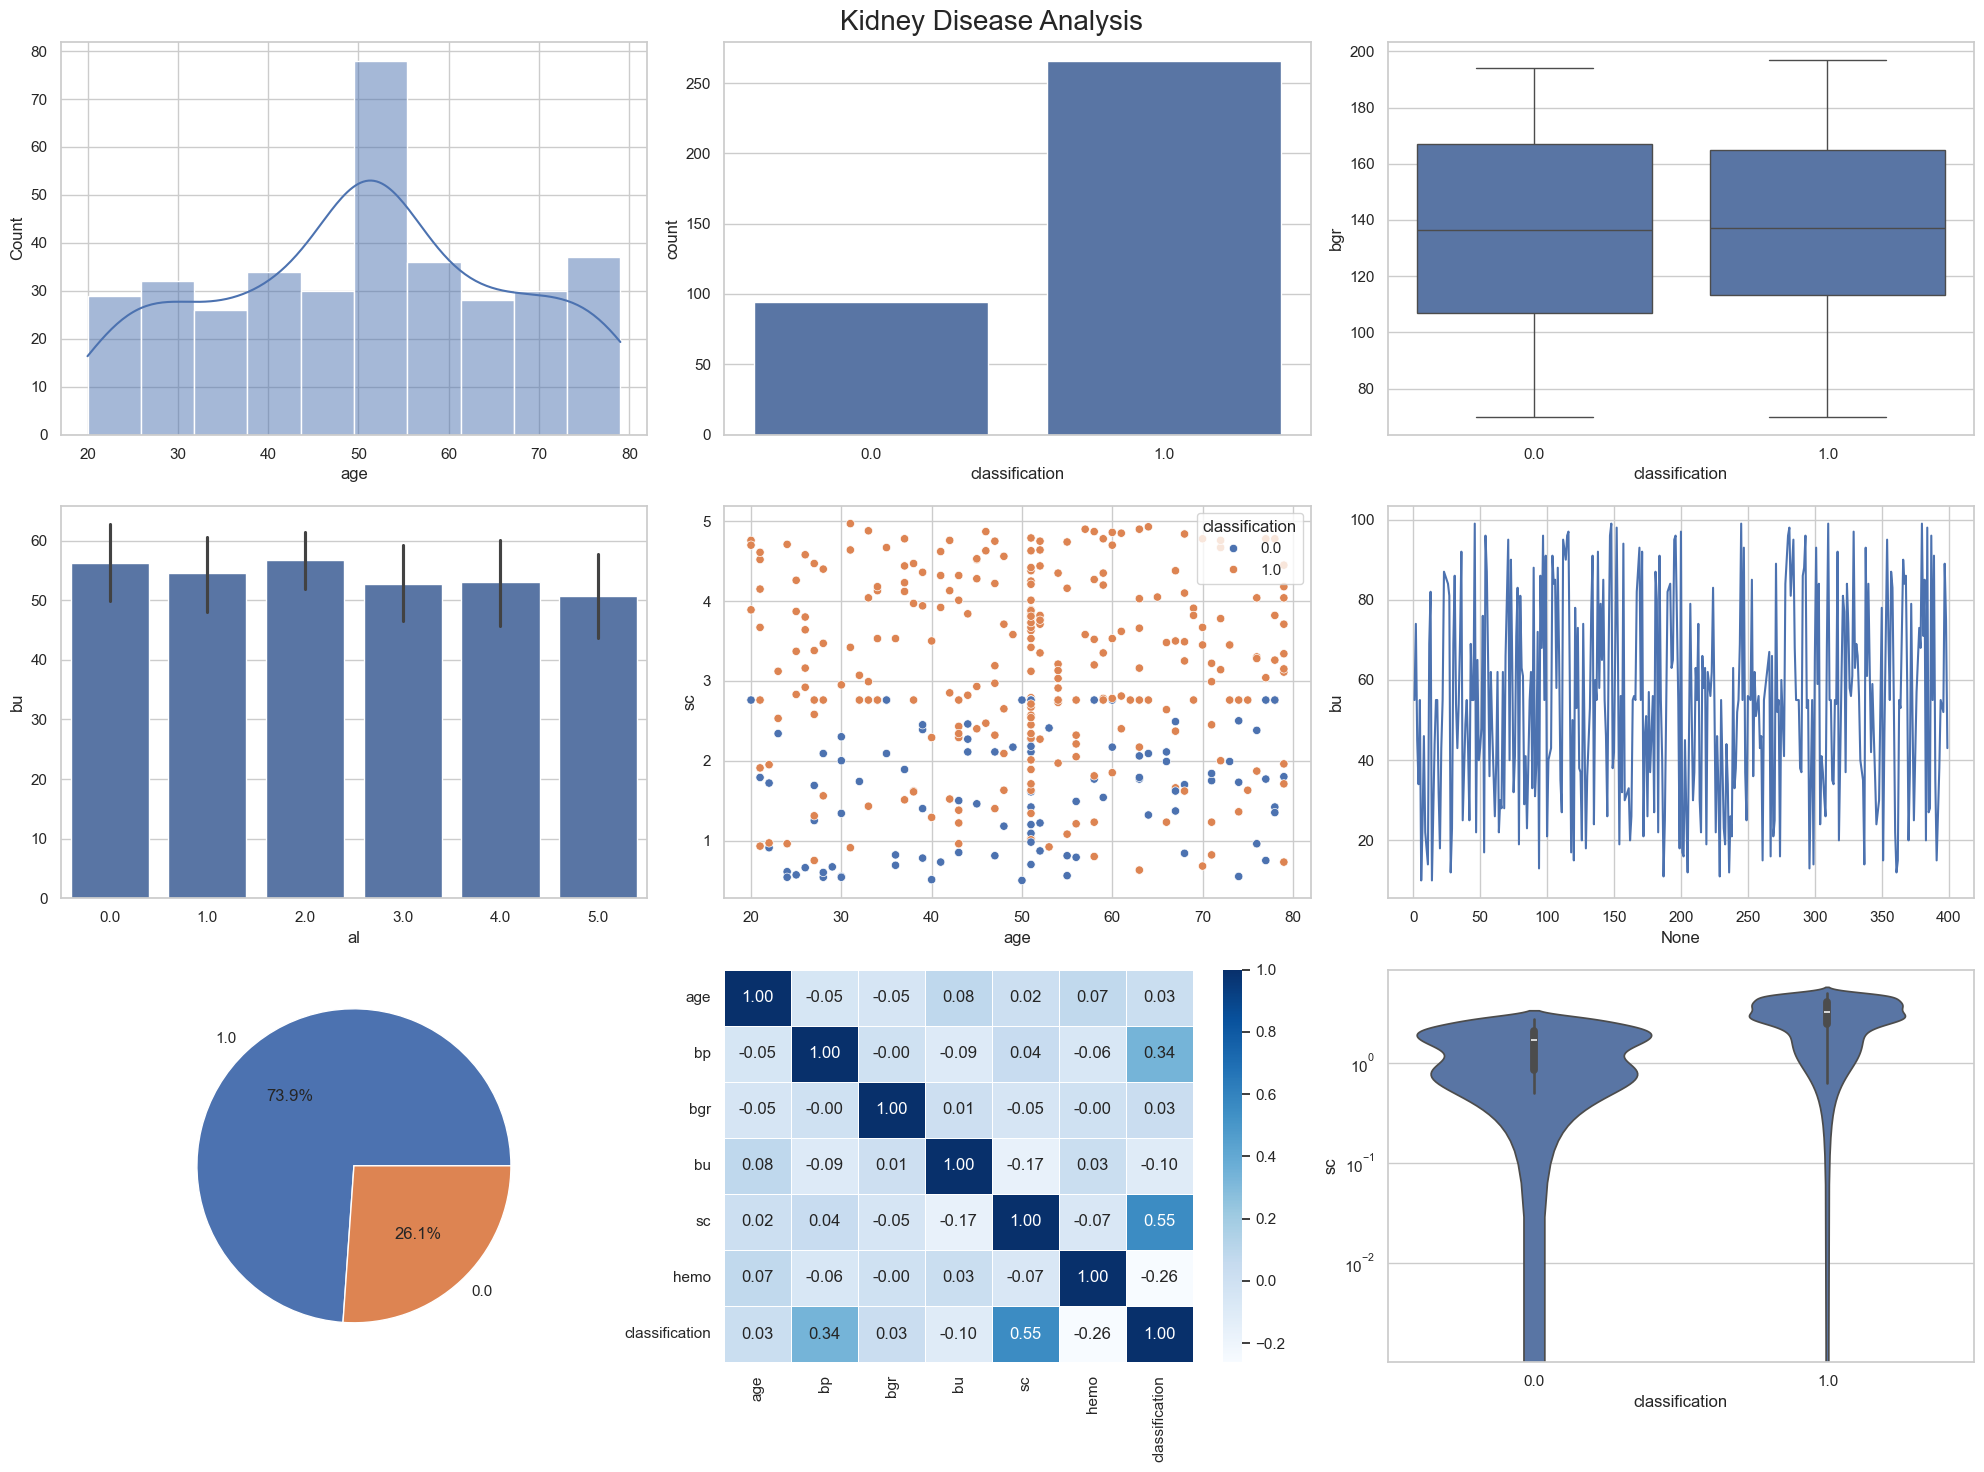

In [9]:
# ==============================
# VISUALIZATION
# ==============================

plt.figure(figsize=(20, 15))
plt.suptitle("Kidney Disease Analysis", fontsize=20)

# 1. Histogram
plt.subplot(3, 3, 1)
sns.histplot(df_kidney["age"], kde=True)

# 2. Countplot
plt.subplot(3, 3, 2)
sns.countplot(x="classification", data=df_kidney)

# 3. Boxplot
plt.subplot(3, 3, 3)
sns.boxplot(x="classification", y="bgr", data=df_kidney)

# 4. Barplot
plt.subplot(3, 3, 4)
sns.barplot(x="al", y="bu", data=df_kidney)

# 5. Scatterplot
plt.subplot(3, 3, 5)
sns.scatterplot(x="age", y="sc", hue="classification", data=df_kidney)

# 6. Lineplot
plt.subplot(3, 3, 6)
sns.lineplot(x=df_kidney.index, y="bu", data=df_kidney)

# 7. Pie Chart
plt.subplot(3, 3, 7)
df_kidney["classification"].value_counts().plot.pie(autopct="%1.1f%%")

# 8. Heatmap
plt.subplot(3, 3, 8)
cols = ["age", "bp", "bgr", "bu", "sc", "hemo", "classification"]
sns.heatmap(df_kidney[cols].corr(), annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)

# 9. Violin Plot
plt.subplot(3, 3, 9)
sns.violinplot(x="classification", y="sc", data=df_kidney)
plt.yscale("log")

plt.tight_layout()
plt.show()

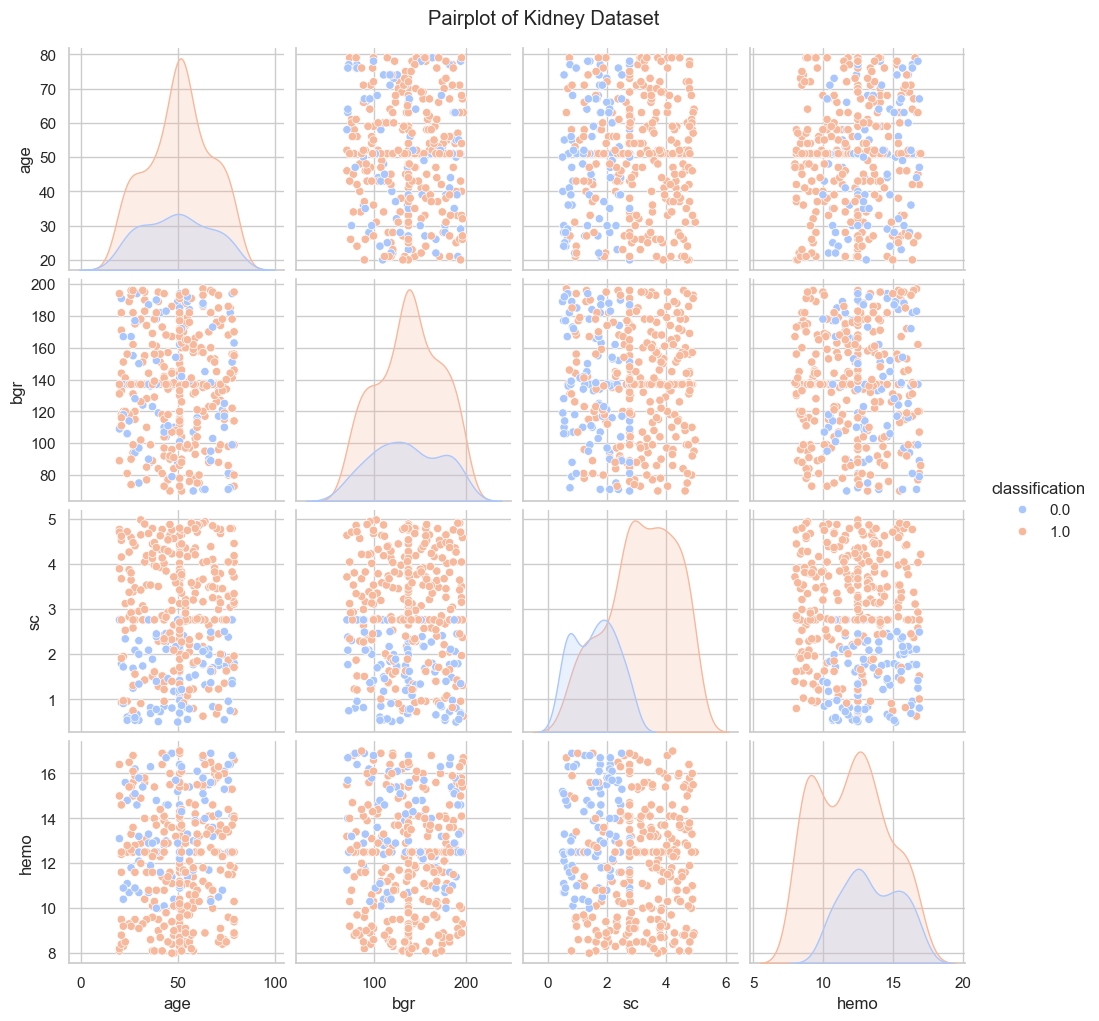

In [10]:
# ==============================
# EXTRA VISUALIZATION - PAIRPLOT
# ==============================

sns.pairplot(
    df_kidney[["age", "bgr", "sc", "hemo", "classification"]],
    hue="classification",
    palette="coolwarm",
)

plt.suptitle("Pairplot of Kidney Dataset", y=1.02)
plt.show()

In [11]:
# ==============================
# MACHINE LEARNING - LOGISTIC REGRESSION
# ==============================

# SMOTE wale resampled data use karo
resampled_columns = X.columns
X_resampled_df = pd.DataFrame(X_resampled, columns=resampled_columns)

# Strong features select karo
feature_cols = ["age", "bp", "bgr", "bu", "sc", "hemo"]
X_final = X_resampled_df[feature_cols]
y_final = pd.Series(y_resampled)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Scale — sirf train pe fit karo
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "kidney_scaler.pkl")

# Logistic Regression
lr_kidney = LogisticRegression(max_iter=3000)
lr_kidney.fit(X_train, y_train)

y_pred_lr = lr_kidney.predict(X_test)

joblib.dump(lr_kidney, "kidney_model.pkl")

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8785046728971962


In [12]:
# ==============================
# MACHINE LEARNING - RANDOM FOREST
# ==============================

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

joblib.dump(rf, "kidney_rf_model.pkl")

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Logistic Regression: 0.8785046728971962
Random Forest Accuracy: 0.9719626168224299


In [13]:
# ==============================
# MODEL EVALUATION
# ==============================

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88        54
         1.0       0.87      0.89      0.88        53

    accuracy                           0.88       107
   macro avg       0.88      0.88      0.88       107
weighted avg       0.88      0.88      0.88       107



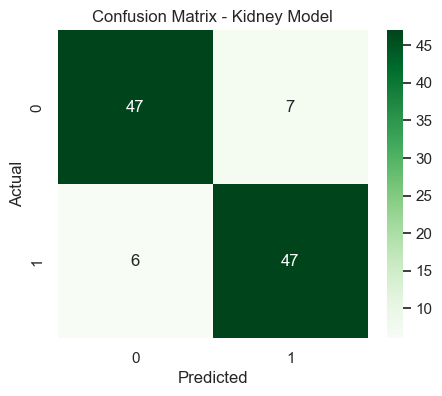

In [14]:
# ==============================
# CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Kidney Model")
plt.show()